In [1]:
import numpy as np
import xarray as xr
import csv
import pandas as pd
import os
import netCDF4 as nc4
import sys

import functions_py.fates_xarray_functions as fa

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib import cm
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.mplot3d import Axes3D

from shapely.geometry import Polygon

/global/homes/j/jneedham/.conda/envs/myenv/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
def szpf_to_scls_by_pft(scpf_var, dataset):
    """function to reshape a fates multiplexed size and pft-indexed variable to one indexed by size class and pft
    first argument should be an xarray DataArray that has the FATES SCPF dimension
    second argument should be an xarray Dataset that has the FATES SCLS dimension 
    (possibly the dataset encompassing the dataarray being transformed)
    returns an Xarray DataArray with the size and pft dimensions disentangled"""
    n_scls = len(dataset.fates_levscls)
    ds_out = (scpf_var.rolling(fates_levscpf=n_scls, center=False)
            .construct("fates_levscls")
            .isel(fates_levscpf=slice(n_scls-1, None, n_scls))
            .rename({'fates_levscpf':'fates_levpft'})
            .assign_coords({'fates_levscls':dataset.fates_levscls})
            .assign_coords({'fates_levpft':dataset.fates_levpft}))
    ds_out.attrs['long_name'] = scpf_var.attrs['long_name']
    ds_out.attrs['units'] = scpf_var.attrs['units']
    return(ds_out)

### Event code 1  = no reforestation 

In [5]:
fates_ec1  = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_dev_testing.Eddc844b10d-F703fde7b.2025-04-02/run/PA_dev_testing.Eddc844b10d-F703fde7b.2025-04-02.sofar.nc'
fates_ec1 = xr.open_dataset(fates_ec1, decode_times=False)

#fates_ec2  = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_dev_testing_ec2b.Eddc844b10d-Fe7658331.2025-04-02/run/PA_dev_testing_ec2b.Eddc844b10d-Fe7658331.2025-04-02.sofar.nc'
fates_ec2 = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_dev_testing_ec2.Eddc844b10d-F703fde7b.2025-04-02/run/PA_dev_testing_ec2.Eddc844b10d-F703fde7b.2025-04-02.sofar.nc'
fates_ec2 = xr.open_dataset(fates_ec2, decode_times=False)

fates_ec5 = '/pscratch/sd/j/jneedham/fates-mrv-runs/runs/PA_dev_testing_ec5b.Eddc844b10d-Fe7658331.2025-04-02/run/PA_dev_testing_ec5b.Eddc844b10d-Fe7658331.2025-04-02.sofar.nc'
fates_ec5 = xr.open_dataset(fates_ec5, decode_times=False)

In [6]:
time1 = fates_ec1.variables['time'] / 365.
time2 = fates_ec2.variables['time'] / 365.
time5 = fates_ec5.variables['time'] / 365.

cohort_size_bins = fates_ec5.variables['fates_levscls'][:]
nsizebins = len(cohort_size_bins)

In [7]:
AGB1 = fates_ec1.FATES_VEGC_ABOVEGROUND_SZPF 
AGB1 = AGB1.sum(dim='fates_levscpf')

AGB2 = fates_ec2.FATES_VEGC_ABOVEGROUND_SZPF  
AGB2 = AGB2.sum(dim='fates_levscpf')

AGB5 = fates_ec5.FATES_VEGC_ABOVEGROUND_SZPF  
AGB5 = AGB5.sum(dim='fates_levscpf')

Text(0.02, 0.5, 'AGB (Kg C m$^{-2}$)')

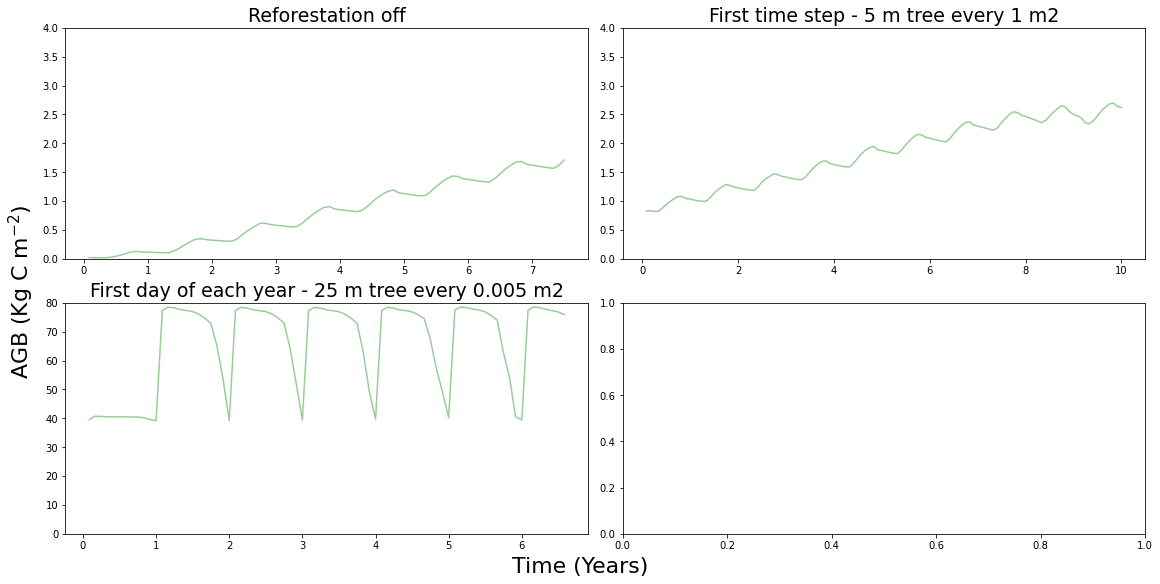

In [11]:
fig1, axs = plt.subplots(nrows=2,ncols=2, figsize=(16,8), constrained_layout=True)

axs=axs.flatten()

axs[0].plot(time1, AGB1, color='green', label = 'FATES', alpha = 0.4)    
axs[0].set_title(r'Reforestation off', fontsize = 19)
axs[0].set_ylim(0,4)

axs[1].plot(time2, AGB2, color='green', label = 'FATES', alpha = 0.4)    
axs[1].set_title(r'First time step - 5 m tree every 1 m2', fontsize = 19)
axs[1].set_ylim(0,4)

axs[2].plot(time5, AGB5, color='green', label = 'FATES', alpha = 0.4)    
axs[2].set_title(r'First day of each year - 25 m tree every 0.005 m2', fontsize = 19)
axs[2].set_ylim(0,80)

fig1.supxlabel(r'Time (Years)', fontsize=22)
fig1.supylabel(r'AGB (Kg C m$^{-2}$)', fontsize=22)

### History output

In [12]:
recruit1 = fates_ec1.FATES_REFORESTATION_PF
recruit2 = fates_ec2.FATES_REFORESTATION_PF
recruit5 = fates_ec5.FATES_REFORESTATION_PF


Text(0.02, 0.5, 'New plant no. m-2 yr-1')

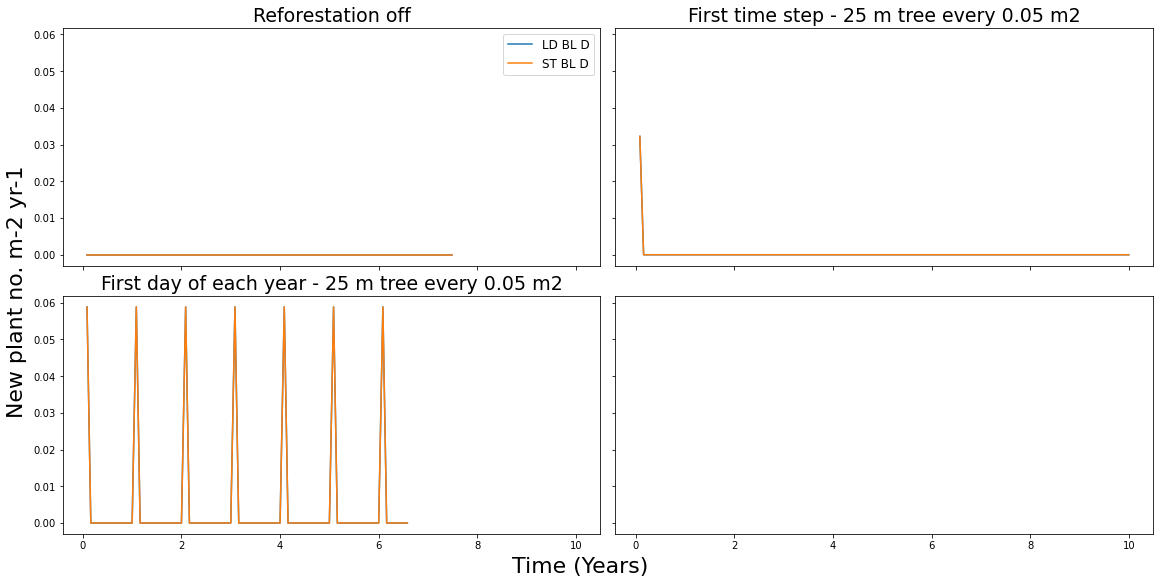

In [15]:
fig1, axs = plt.subplots(nrows=2,ncols=2, figsize=(16,8), sharex=True, sharey=True, constrained_layout=True)

axs=axs.flatten()

axs[0].plot(time1, recruit1.isel(fates_levpft=0),label = 'LD BL D')  
axs[0].plot(time1, recruit1.isel(fates_levpft=1), label = 'ST BL D')      
axs[0].legend(prop={'size':12})
axs[0].set_title(r'Reforestation off', fontsize = 19)

axs[1].plot(time2, recruit2.isel(fates_levpft=0),label = 'LD BL D')  
axs[1].plot(time2, recruit2.isel(fates_levpft=1), label = 'ST BL D')   
axs[1].set_title(r'First time step - 25 m tree every 0.05 m2', fontsize = 19)

axs[2].plot(time5, recruit5.isel(fates_levpft=0),label = 'LD BL D')  
axs[2].plot(time5, recruit5.isel(fates_levpft=1), label = 'ST BL D') 
axs[2].set_title(r'First day of each year - 25 m tree every 0.05 m2', fontsize = 19)

fig1.supxlabel(r'Time (Years)', fontsize=22)
fig1.supylabel(r'New plant no. m-2 yr-1', fontsize=22)

### Are new plants being terminated because canopy is full? 

In [14]:
MORT_T_SZPF = szpf_to_scls_by_pft(fates_ec5.FATES_MORTALITY_TERMINATION_SZPF, fates_ec5)
NPLANT_SZPF = szpf_to_scls_by_pft(fates_ec5.FATES_NPLANT_SZPF, fates_ec5) 

In [ ]:
# set up the page
fig3, ((f3ax0)) = plt.subplots(nrows=1, ncols=1, figsize=(15, 7))

## set up the first plot: growth rate (in diameter increment) in the canopy
levels = np.arange(0.,1.0, 0.01)
cmap = plt.get_cmap('Reds')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
im = f3ax0.pcolormesh(time5, cohort_size_bins, np.squeeze(MORT_T_SZPF.isel(fates_levpft=0) / NPLANT_SZPF.isel(fates_levpft=0)).transpose(), cmap=cmap, norm=norm)
fig3.colorbar(im, ax=f3ax0)
f3ax0.set_title(r'Termination mortality rate - LD PFT', fontsize=26)
f3ax0.set_xlabel('Time (yr)', fontsize=26)
f3ax0.set_ylabel('Cohort Size (cm)', fontsize=26)
